## Autonomous Planner Agent | Orchestrator-Worker Workflow | LangGraph | v2

### Problem Statement

An intelligent system that coordinates multiple specialized
agents to search flights, hotels, plan itineraries, and provide
personalized travel recommendations.



[<img src="image-1.png" width="700"/>](image-1.png)


### Step 1: Setup

In [ ]:
import os
import json
from dotenv import load_dotenv
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from uuid import uuid4 as uuid
from datetime import date

In [ ]:
load_dotenv()

openAI_key = os.getenv("openAI_key")
tavily_key = os.getenv("tavily_key")
serpapi_key = os.getenv("serpapi_key")

In [ ]:
from typing import Annotated, List
import operator
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain.tools import tool
from typing_extensions import TypedDict
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.constants import Send
from pydantic import BaseModel, Field

C:\Users\iamni\AppData\Local\Temp\ipykernel_30740\4216800769.py:11: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [ ]:
# for retry issues
# 429 Rate Limit
# Connection timeout
# Temporary network issue
# 502 / 503

from tenacity import retry
from tenacity import stop_after_attempt
from tenacity import wait_exponential

In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.4, openai_api_key=openAI_key)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small", openai_api_key=openAI_key)

In [ ]:
# test model


response = llm.invoke("Hello, how are you?")
print(response.content)

del response

embeddings_response = embeddings.embed_documents(["Hello", "Bye"])
print(embeddings_response[0][:5])

del embeddings_response

Hello! I'm just a program, but I'm here and ready to help you. How can I assist you today?
[0.019256591796875, -0.06451416015625, -0.0016851425170898438, 0.07818603515625, 0.021636962890625]


### Step 2: Define State

In [ ]:
class WorkerResult(TypedDict):
    worker_name: str
    output: str

class State(TypedDict):
    user_input: str
    selected_workers: List[str]
    worker_outputs: Annotated[List[WorkerResult], operator.add]
    messages: Annotated[List[AnyMessage], add_messages]
    final_output: str

state = State()

In [ ]:
def dispatch_workers(state: State):
    "It is just deciding the next node, not executing as a node. So it is not a node, but a function that decides the next node to execute."
    selected_workers = state.get("selected_workers", [])

    if not selected_workers:
        return "end"

    return [
        Send(worker, state)
        for worker in selected_workers
    ]

### Step 3: Orchestrator-Worker Node

In [ ]:
agent_description = {
    "travel_planning_agent": """
        Helps in Travel Planning, Flight and Hotel Booking, Flight Recommendations, Hotel Recommendations.
    """,
    "itinerary_agent": """
        Itinerary Planning, Site-seeing Recommendations, Local Experience Recommendations, Food Recommendations.
    """
}

agent_embeddings = {}

for agent_name, description in agent_description.items():
    agent_embeddings[agent_name] = embeddings.embed_query(description)

with open("agent_embeddings.json", "w") as f:
    json.dump(agent_embeddings, f)

del agent_embeddings, agent_description

In [ ]:
@tool
def route_selection(query: str) -> List[str]:
    """Selects the appropriate route (agent) based on the user query."""
    input_embedding = np.array(embeddings.embed_query(query)).reshape(1, -1)

    with open("agent_embeddings.json", "r") as f:
        AGENT_EMBEDDINGS = json.load(f)

    travel_planner_embedding = np.array(AGENT_EMBEDDINGS["travel_planning_agent"]).reshape(1, -1)
    itinerary_embedding = np.array(AGENT_EMBEDDINGS["itinerary_agent"]).reshape(1, -1)

    travel_score = cosine_similarity(input_embedding, travel_planner_embedding)[0][0]
    itinerary_score = cosine_similarity(input_embedding, itinerary_embedding)[0][0]

    if abs(travel_score - itinerary_score) < 0.05:
        return ["travel_planning_agent", "itinerary_agent"]
    if travel_score > itinerary_score:
        return ["travel_planning_agent"]
    else:
        return ["itinerary_agent"]

In [ ]:
def orchestrator(state: State) -> str:
    """Orchestrates the workflow based on the current state and user input."""

    user_input = state["user_input"]
    history = state.get("messages", []) or []

    orchestrator_llm = llm.bind_tools([route_selection])

    prompt_template = """
        You are an orchestrator-worker manager.

        You have access to the tool:
        - route_selection

        Call route_selection ONLY when the latest user query asks for a NEW:
        - trip planning
        - travel planning
        - hotel booking
        - flight booking
        - itinerary generation

        Do NOT call route_selection for follow-up questions like:
        - summarize the plan
        - make it shorter
        - explain the previous plan
        - what was the hotel?
        - what was the flight?

        For follow-up questions:
        - Use conversation history.
        - If the user asks to summarize, provide a concise summary of the existing plan.
        - Preserve important named details from the previous plan, including:
            - flight airline/name and price if available
            - hotel name and price if available
            - key sightseeing/location names
            - travel dates
        - Do not include full raw details like every flight timing, every hotel field, or full itinerary paragraphs.
        - Do not add new information.

    """
    messages = [
        SystemMessage(content=prompt_template),
        *history,
        HumanMessage(content=user_input)
    ]

    response = orchestrator_llm.invoke(messages)

    print("Tool calls:", response.tool_calls)

    if response.tool_calls:
        tool_call = response.tool_calls[0]
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        if tool_name == "route_selection":
            selected_route = route_selection.invoke(tool_args)
            print(f"Selected Route: {selected_route}")

            return {
                "selected_workers": selected_route,
                "messages": [
                    HumanMessage(content=user_input)
                ]
            }

    return {
        "selected_workers": [],
        "final_output": response.content,
        "messages": [
            HumanMessage(content=user_input),
            AIMessage(content=response.content)
        ]
    }

### Step 4: Worker Tools

In [ ]:
from langchain_tavily import TavilySearch

tavilyClient = TavilySearch(
    max_results=5,
    tavily_api_key=tavily_key
)

from serpapi import Client

serpClient = Client(api_key=serpapi_key)

In [ ]:
# test apis

results = tavilyClient.invoke({"query": "what is langchain", "search_depth": "advanced"})
print(json.dumps(results["results"], indent=2))

del results



[
  {
    "url": "https://www.techtarget.com/searchenterpriseai/definition/LangChain",
    "title": "What Is LangChain and How to Use It: A Guide | Definition from TechTarget",
    "content": "# What is LangChain and how to use it: A guide\n\nBy\n\n Kinza Yasar, Technical Writer\n Cameron Hashemi-Pour, Former Site Editor\n\nPublished: Jan 02, 2025\n\nLangChain is an open source framework that enables software developers working with artificial intelligence (AI) and its machine learning subset to combine large language models with other external components to develop LLM-powered applications.\n\nLangChain aims to link powerful LLMs, such as OpenAI's GPT-3.5 and GPT-4, to an array of external data sources to create and reap the benefits of natural language processing (NLP) applications. It's also used for creating interfaces that produce humanlike responses and answer questions. [...] Retrieval modules. LangChain supports the development of RAG systems with tools for transforming, storin

In [ ]:
# params = {
#   "engine": "google_flights",
#   "departure_id": "DEL",   # Delhi
#   "arrival_id": "BOM",     # Mumbai
#   "outbound_date": "2026-06-17",
#   "return_date": "2026-06-23",
#   "currency": "INR",
#   "adults": 1
# }

params = {
  "engine": "google",
  "q": "Delhi airpot code"
}

results = serpClient.search(params).as_dict()

print(results)

del results, params

{'search_metadata': {'id': '6a338db5de1f3341e49c1f57', 'status': 'Success', 'json_endpoint': 'https://serpapi.com/searches/uOuPN5Tuq4-1B4-IxRDOEw/6a338db5de1f3341e49c1f57.json', 'pixel_position_endpoint': 'https://serpapi.com/searches/uOuPN5Tuq4-1B4-IxRDOEw/6a338db5de1f3341e49c1f57.json_with_pixel_position', 'created_at': '2026-06-18 06:18:29 UTC', 'processed_at': '2026-06-18 06:18:29 UTC', 'google_url': 'https://www.google.com/search?q=Delhi+airpot+code&oq=Delhi+airpot+code&sourceid=chrome&ie=UTF-8', 'raw_html_file': 'https://serpapi.com/searches/uOuPN5Tuq4-1B4-IxRDOEw/6a338db5de1f3341e49c1f57.html', 'total_time_taken': 6.74}, 'search_parameters': {'engine': 'google', 'q': 'Delhi airpot code', 'google_domain': 'google.com', 'device': 'desktop'}, 'search_information': {'query_displayed': 'Delhi airpot code', 'total_results': 133, 'time_taken_displayed': 0.31, 'organic_results_state': 'Some results for exact spelling but showing fixed spelling', 'spelling_fix': 'Delhi airport code', 'sh

In [ ]:
# functional methods, not tools

@retry(
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=1)
)
def search_serpapi(params):
    return serpClient.search(params)

@retry(
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=1)
)
def search_tavily(query):
    return tavilyClient.invoke(
        {
            "query": query,
            "search_depth": "advanced"
        }
    )

In [ ]:
@tool
def get_iata_codes(query: str) -> List[str]:
    """
        Extract departure and arrival cities from a flight/trip query and return their IATA airport codes.

        Args:
            query: User travel query containing departure and arrival locations.

        Returns:
            A list of two strings: [departure_iata_code, arrival_iata_code].
            If either code cannot be determined, that value is "N/A".
    """


    prompt_template = """
    You are an assistant that helps in extracting location information from user queries for flight booking.

    Example:
    1. If the user query is "Plan a trip from Delhi to Mumbai",
    then you should extract the departure and arrival locations as "Delhi" and "Mumbai", respectively.

    response:
    {{
        "departure_location": "Delhi",
        "arrival_location": "Mumbai"
    }}

    2. If the user query is "Plan a trip to Los Angeles",
    response:
    {{
        "departure_location": "N/A",
        "arrival_location": "Los Angeles"
    }}

    3. If the user query is "Plan a trip from delhi to mumbai for 23rd June to 1st of July."

    response:
    {{
        "departure_location": "Delhi",
        "arrival_location": "Mumbai"
    }}


    User Query:
    {query}

    Reminder:
    - Extract the departure and arrival locations from the user query.
    - Do not extract any other information.
    - Always return the response in the specified JSON format and with the same keys.
    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)

    response = (PROMPT | llm | JsonOutputParser()).invoke({"query": query})

    iata_list = []

    print(response)

    for _, value in response.items():
        city = value.strip()

        if city == "N/A":
            iata_list.append("N/A")
            continue

        iata_list.append(city)

    prompt_template = """
        You are expert in finding the IATA code for the provided cities.
        You will have dict which has city names as keys and their respective IATA codes as values.
        Use the IATA_codes dict to find the correct IATA code for the user's departure and arrival location.

        User Query:
        {iata_list}

        IATA_codes dict:
        {IATA_codes}

        Response Format:
        {{
            "Depature_id": "IATA Code",
            "Arrival_id": "IATA Code"
        }}

        Remember:
        - Only provide the IATA code for that particular city which is mentioned in the user query.
        - If not found, then provide value as N/A, don't hallucinate and create random IATA code.

        Example:
        1. If the user query list is:
        {{
            "departure_location": "Delhi",
            "arrival_location": "Mumbai"
        }}

        Then the response is:
        {{
            "Depature_id": "DEL",
            "Arrival_id": "BOM"
        }}

        2. If the user query list is:
        {{
            "departure_location": "Delhi",
            "arrival_location": "Shimla"
        }}

        Then the response is:
        {{
            "Depature_id": "DEL",
            "Arrival_id": "N/A"
        }}
    """

    IATA_codes = {
        "Delhi": "DEL",
        "Mumbai": "BOM",
        "Tokyo": "NRT",
        "Bangalore": "BLR"
    }

    PROMPT = ChatPromptTemplate.from_template(prompt_template)
    response = (PROMPT | llm | JsonOutputParser()).invoke(
        {"iata_list": iata_list, "IATA_codes": IATA_codes}
    )

    final_list = []

    final_list.append(response.get('Depature_id', 'N/A'))
    final_list.append(response.get('Arrival_id', 'N/A'))

    print(final_list)

    return final_list

class FlightBookingInput(BaseModel):
    query: str = Field(description="Original user query with travel dates and passenger count.")
    iata_codes: List[str] = Field(
        description="Two IATA airport codes in order: [departure_code, arrival_code]. Example: ['DEL', 'BOM']"
    )

@tool(args_schema=FlightBookingInput)
def flight_booking_tool(query: str, iata_codes: List[str]) -> dict:
    """
        Search Google Flights using SerpAPI.

        Args:
            query: Original user query containing travel dates and passenger count.
            iata_codes: List of two IATA codes in this order: [departure_code, arrival_code].

        Returns:
            JSON string containing flight search results, or an error/skipped message.
    """

    prompt_template = """
        You are a flight booking agent.
        You have access to the SerpAPI for flight booking related queries.
        Use the SerpAPI to answer the user query related to flight booking using google flights engine.

        SerpAPI takes google flights engine takes parameters like departure_id, arrival_id, outbound_date, return_date, currency, and adults.

        Important Information:
        - Today's date is {today_date}.
        - Departure and Arrival IDs are the IATA codes for airports are {depature_codes} and {arrival_codes}, respectively.

        Response Format:
        {{
            "outbound_date": "YYYY-MM-DD",
            "return_date": "YYYY-MM-DD",
            "adults": number
        }}

        User Query:
        {query}


        For example,
        1. if the user query is:
        "Book a flight from Delhi to Mumbai on 17th June 2026 and return on 23rd June 2026 for 1 adult",
        you should extract the parameters and call the SerpAPI with those parameters.

        response = {{
            "outbound_date": "2026-06-17",
            "return_date": "2026-06-23",
            "adults": 1
        }}

        2. if the user query is:
        "Find me a flight from New York to Los Angeles",
        you should extract the parameters and call the SerpAPI with those parameters, and if no dates are provided, then it will be 5 days round trip from next week monday.
        And if no adults are provided, then it will be 1 adult.

        response = {{
            "outbound_date": "2026-07-22",
            "return_date": "2026-07-26",
            "adults": 1
        }}

        3. if the user query is:
        "Find me a flight from New York to Los Angeles on 22nd July 2026 and return on 26th July 2026 for 2 adults",
        you should extract the parameters and call the SerpAPI with those parameters.

        response = {{
            "outbound_date": "2026-07-22",
            "return_date": "2026-07-26",
            "adults": 2
        }}

        Reminder:
        - If the user query is not related to flight booking, then do not call the SerpAPI and answer directly.
        - If the user query is related to flight booking, then call the SerpAPI with the extracted parameters and return the results.
        - If the user query is related to flight booking, then do not answer directly and only call the SerpAPI with the extracted parameters and return the results.
        - Results should be returned in the specified JSON format and with the same keys.

    """

    if (len(iata_codes) != 2 or "N/A" in iata_codes):
        return {
            "status": "skipped",
            "tool_name": "flight_booking_tool",
            "reason": "Missing departure or arrival IATA code",
            "data": None
        }

    PROMPT = ChatPromptTemplate.from_template(prompt_template)

    try:
        response = (PROMPT | llm | JsonOutputParser()).invoke({
            "today_date": date.today().strftime("%Y-%m-%d"),
            "depature_codes": iata_codes[0],
            "arrival_codes": iata_codes[1],
            "query": query
        })

        params = {
            "engine": "google_flights",
            "departure_id": iata_codes[0],
            "arrival_id": iata_codes[1],
            "outbound_date": response["outbound_date"],
            "return_date": response["return_date"],
            "currency": "INR",
            "adults": response["adults"]
        }

        results = search_serpapi(params=params)

        return {
        "status": "success",
        "tool_name": "flight_booking_tool",
        "params": params,
        "data": results.as_dict()
    }
    except Exception as e:
        return {
            "status": "error",
            "tool_name": "flight_booking_tool",
            "message": str(e),
            "data": None
        }


@tool
def hotel_booking_tool(query: str) -> dict:
    """
        Search hotels using SerpAPI.

        Args:
            query: Original user query containing destination, check-in/check-out dates, and adults.

        Returns:
            JSON string containing hotel search results, or an error message.
    """

    prompt_template = """
        You are a hotel booking agent.
        You have to build a parameter dictionary for the SerpAPI for hotel booking related queries.

        SerpAPI takes google hotels engine takes parameters like location, checkin_date, checkout_date, currency, and adults.

        Important Information:
        - Today's date is {today_date}.

        Response Format:
        {{
            "location": <str>,
            "checkin_date": <YYYY-MM-DD>,
            "checkout_date": <YYYY-MM-DD>,
            "adults": number
        }}

        User Query:
        {query}

        Example:
        1. 1. if the user query is:
        "Book a flight from Delhi to Mumbai on 17th June 2026 and return on 23rd June 2026 for 1 adult",
        then exract the destination locaiton as Mumbai, number of adults as 1 and checkin_date as 2026-06-17 and checkout_date is 2026-06-23,
        and format it according to response format.

        Reminder:
        - If the user query is related to hotel booking, then do not answer directly and only create a parameter dictionary for using response format for the SerpAPI   and return the results.
        - Results should be returned in the specified JSON format and with the same keys.

    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)
    try:
        response = (PROMPT | llm | JsonOutputParser()).invoke({
            "today_date": date.today().strftime("%Y-%m-%d"),
            "query": query
        })

        params = {
            "engine": "google_hotels",
            "q": response["location"],
            "check_in_date": response["checkin_date"],
            "check_out_date": response["checkout_date"],
            "currency": "INR",
            "adults": response["adults"]
        }

        results = search_serpapi(params=params)

        return {
            "status": "success",
            "tool_name": "hotel_booking_tool",
            "params": params,
            "data": results.as_dict()
        }
    except Exception as e:
        return {
            "status": "error",
            "tool_name": "hotel_booking_tool",
            "message": str(e),
            "data": None
        }

@tool
def itinerary_planning_tool(query: str) -> str:
    """Using the Tavily API for itinerary planning related queries."""
    prompt_template = """
        You are an itinerary planning agent.
        Re-write the query to be more specific and clear for the Tavily API for itinerary planning related queries.



        User Query:
        {query}

        Example:
        1. If the user query is "Plan a 3-day trip to Paris for 2 adults",
        then you should re-write the query to be more specific and clear for the Tavily API.
        response = "Plan a 3-day trip to Paris for 2 adults, including sightseeing, local experiences, and food recommendations."


        Reminder:
        - If the user query is related to itinerary planning, then do not answer directly and only re-write the query to be more specific and clear for the Tavily API to consume.
        - Return only the rewritten query.
        - Do not return JSON, only return string.

    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)

    response = (PROMPT | llm | StrOutputParser()).invoke({
        "query": query
    })

    results = search_tavily(query=query)

    filtered_results = [
        {
            "title": r.get("title"),
            "content": r.get("content")
        }
        for r in results["results"]
    ]

    return json.dumps(filtered_results, indent=2)

### Step 5: Worker Agents

In [ ]:
def travel_planning_agent(state: State) -> str:
    """Main function for the travel planning agent."""
    user_input = state["user_input"]
    worker_results = []

    tools = [
        get_iata_codes,
        flight_booking_tool,
        hotel_booking_tool
    ]

    tool_map = {
        "get_iata_codes": get_iata_codes,
        "flight_booking_tool": flight_booking_tool,
        "hotel_booking_tool": hotel_booking_tool
    }

    travel_llm = llm.bind_tools(tools)

    prompt_template = """
        You are a travel planning agent.

        Your job is to help with:
        - flight search
        - hotel search
        - complete trip planning

        You have access to these tools:
        1. get_iata_codes
        - Use this first when flight search is needed.
        - It extracts departure and arrival IATA airport codes.

        2. flight_booking_tool
        - Use this only after get_iata_codes.
        - It searches flight options using the user query and IATA codes.

        3. hotel_booking_tool
        - Use this when hotel search is needed.
        - It searches hotel options for the destination city and travel dates.

        [Important] Before calling flight_booking_tool:
        - First call get_iata_codes.
        - Inspect the returned IATA codes.
        - If either departure or arrival IATA code is "N/A", DO NOT call flight_booking_tool.
        - Instead, explain that flight search cannot be performed because one or more airport codes could not be determined.
        - Continue with hotel search if hotel information is still required.

        Tool calling rules:

        Call flight tools when:
        - The user asks for flights.
        - The user asks to plan a trip/vacation.
        - The user asks for complete travel planning.

        Flight tool order:
        1. get_iata_codes
        2. flight_booking_tool

        Call hotel_booking_tool when:
        - The user asks for hotels.
        - The user asks to plan a trip/vacation.
        - The user asks for complete travel planning.

        Do not call flight tools when:
        - The user asks only for hotels.

        Do not call hotel_booking_tool when:
        - The user asks only for flights.

        Examples:

        User: Plan a trip from Delhi to Mumbai.
        Action:
        - Call get_iata_codes
        - Call flight_booking_tool
        - Call hotel_booking_tool

        User: Provide flight details from Delhi to Mumbai.
        Action:
        - Call get_iata_codes
        - Call flight_booking_tool

        User: Provide hotel details in Mumbai.
        Action:
        - Call hotel_booking_tool

        Return only the final answer based on tool outputs.
        Do not invent flight or hotel details.

    """

    messages = [
        SystemMessage(content=prompt_template),
        HumanMessage(content=user_input)
    ]

    for _ in range(5):
        response = travel_llm.invoke(messages)

        messages.append(response)

        if not response.tool_calls:
            worker_results.append({
                "worker_name": "travel_planning_agent",
                "output": response.content
            })

            return {
                "worker_outputs": worker_results
            }

        for tool_call in response.tool_calls:
            tool_name = tool_call["name"]
            tool_args = tool_call["args"]

            try:
                tool_result = tool_map[tool_name].invoke(tool_args)
            except Exception as e:
                tool_result = {
                    "status": "error",
                    "tool_name": tool_name,
                    "message": str(e),
                    "data": None
                }

            print(f"\nTool Executed: {tool_name}")

            if isinstance(tool_result, dict) and tool_result.get("status") == "skipped":
                print(f"{tool_name} was skipped")

            messages.append(
                ToolMessage(
                    content=json.dumps(tool_result, default=str),
                    tool_call_id=tool_call["id"]
                )
            )


    return {
        "worker_outputs": [{
            "worker_name": "travel_planning_agent",
            "output": "Travel planning stopped because tool-calling loop reached max iterations."
        }]
    }

def itinerary_agent(state: State) -> str:
    """Main function for the itinerary planning agent."""
    user_input = state["user_input"]

    itinerary_results = itinerary_planning_tool.invoke(user_input)

    return {
        "worker_outputs": [{
            "worker_name": "itinerary_agent",
            "output": itinerary_results
        }]
    }


def synthesize_results(state: State) -> str:
    """Synthesizes the results from different agents and provides a final response."""
    worker_outputs = state.get("worker_outputs", [])

    if not worker_outputs:
        response = "I could not generate a final plan because no agent outputs were available."
        return {
            "final_output": response,
            "messages": [AIMessage(content=response)]
        }

    final_context = "Here are the results from the different agents:\n\n"

    for item in worker_outputs:
        output = item["output"]

        if isinstance(output, dict):
            output_text = json.dumps(output, indent=2, default=str)
        else:
            output_text = str(output)

        final_context += f"{output_text}\n\n"

    prompt_template = """
        You are a synthesis agent.
        Your task is to synthesize ONLY the results from different agents and provide a final response to the user.

        Use the results from travel_planning_agent and itinerary_agent to provide a comprehensive response to the user query.

        It is possible that, one of the agent does't provide the information needed and might say unable, could not, or failed to find
        the required information. In that case don't use that agent's information when synthesizing the final output.

        User Query:
        {user_input}

        Agent Output:
        {final_context}

        Reminder:
        - Provide a comprehensive response to the user query using the results from different agents.
        - Do not include any irrelevant information.
        - Always return the response in a clear and concise manner.
        - Always find the cheapest flight and hotel options for the user query from the travel_planning_agent Output.
        - Provide a summary of the itinerary from the itinerary_agent Output.
        - It is possible that only one
        - Do not use external sources for information, only use the results from the agents.
    """

    PROMPT = ChatPromptTemplate.from_template(prompt_template)

    chain = PROMPT | llm | StrOutputParser()

    response = ""

    for chunk in chain.stream({
        "user_input": state["user_input"],
        "final_context": final_context
    }):
        print(chunk, end="", flush=True)
        response += chunk

    return {
        "worker_outputs": [{
            "worker_name": "synthesis_agent",
            "output": response
        }],
        "messages": [AIMessage(content=response)],
        "final_output": response
    }

### Step 6: Build Graph

In [ ]:
from langgraph.graph import StateGraph, START, END

build = StateGraph(State)

build.add_node("travel_planning_agent", travel_planning_agent)
build.add_node("itinerary_agent", itinerary_agent)
build.add_node("synthesize_results", synthesize_results)
build.add_node("orchestrator", orchestrator)

build.add_edge(START, "orchestrator")

build.add_conditional_edges(
    "orchestrator",
    dispatch_workers,
    {
        "travel_planning_agent": "travel_planning_agent",
        "itinerary_agent": "itinerary_agent",
        "end": END
    }
)

build.add_edge("travel_planning_agent", "synthesize_results")
build.add_edge("itinerary_agent", "synthesize_results")

build.add_edge("synthesize_results", END)

graph = build.compile()

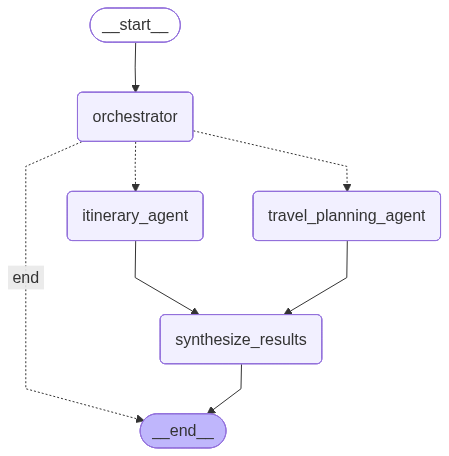

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Step 7: Persistance

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = build.compile(checkpointer=memory)

In [ ]:
def new_thread():
    """Creates a new session/thread id for memory management."""
    return {
        "configurable": {
            "thread_id": str(uuid())
        }
    }

## Test

In [ ]:
config = new_thread()

result = graph.invoke(
    {
        "user_input": "Plan a trip from Delhi to Mumbai on 20th June 2026 and return on 28rd June 2026 for 1 adult. Also, provide an itinerary for the trip.",
        "selected_workers": [],
        "worker_outputs": [],
        "messages": [],
        "final_output": ""
    },
    config=config
)

print(result["final_output"])


Tool calls: [{'name': 'route_selection', 'args': {'query': 'Plan a trip from Delhi to Mumbai on 20th June 2026 and return on 28th June 2026 for 1 adult. Also, provide an itinerary for the trip.'}, 'id': 'call_xV0fOOW6nO8EF8BVlD3QwZBE', 'type': 'tool_call'}]
Selected Route: ['travel_planning_agent', 'itinerary_agent']
{'departure_location': 'Delhi', 'arrival_location': 'Mumbai'}
['DEL', 'BOM']

Tool Executed: get_iata_codes

Tool Executed: flight_booking_tool

Tool Executed: hotel_booking_tool
### Trip Plan from Delhi to Mumbai (20th June 2026 - 28th June 2026)

#### **Flight Details:**
- **Departure:**
  - **Airline:** IndiGo
  - **Flight Number:** 6E 675
  - **Departure Airport:** Indira Gandhi International Airport (DEL)
  - **Departure Time:** 20th June 2026, 08:45 AM
  - **Arrival Airport:** Chhatrapati Shivaji Maharaj International Airport (BOM)
  - **Arrival Time:** 20th June 2026, 11:00 AM
  - **Duration:** 2 hours 15 minutes
  - **Price:** ₹14,644 (round trip)

- **Return:**
  

In [ ]:
result = graph.invoke(
    {
        "user_input": "Summarise the plan",
        "selected_workers": [],
        "worker_outputs": [],
        "messages": [],
        "final_output": ""
    },
    config=config
)

print(result["final_output"])

Tool calls: []
### Trip Summary from Delhi to Mumbai (20th June 2026 - 28th June 2026)

- **Flights:**
  - **Departure:** IndiGo flight 6E 675, from Delhi (DEL) on 20th June at 08:45 AM, arriving in Mumbai (BOM) at 11:00 AM.
  - **Return:** IndiGo flight 6E 675, from Mumbai (BOM) on 28th June at 11:00 AM, arriving in Delhi (DEL) at 01:15 PM.
  - **Total Flight Price:** ₹14,644 (round trip).

- **Hotel:**
  - **Name:** Radisson Blu Mumbai International Airport
  - **Check-in:** 20th June 2026
  - **Check-out:** 28th June 2026
  - **Price:** ₹13,374 per night, total ₹93,618 for 7 nights.

- **Total Estimated Cost:** ₹108,262.

- **Itinerary Highlights:**
  - Explore major attractions like Gateway of India, Elephanta Caves, Marine Drive, and local markets.
  - Day trip options to Lonavala or Khandala.
  - Relaxation and leisure activities included.

Let me know if you need any more details!


In [ ]:
state = graph.get_state(config)

print("STATE KEYS:", state.values.keys())
print("MESSAGES:", state.values.get("messages"))

STATE KEYS: dict_keys(['user_input', 'selected_workers', 'worker_outputs', 'messages', 'final_output'])
MESSAGES: [HumanMessage(content='Plan a trip from Delhi to Mumbai on 17th June 2026 and return on 23rd June 2026 for 1 adult. Also, provide an itinerary for the trip.', additional_kwargs={}, response_metadata={}, id='e20a67fe-10e6-47dc-876f-a6b4a57980bb'), AIMessage(content="### Trip Plan: Delhi to Mumbai (17th June 2026 - 23rd June 2026)\n\n#### **Flight Details:**\n- **Departure:**\n  - **Flight:** Air India Express IX 1235\n  - **From:** Indira Gandhi International Airport (DEL)\n  - **To:** Chhatrapati Shivaji Maharaj International Airport (BOM)\n  - **Departure Time:** 17th June 2026, 23:25\n  - **Arrival Time:** 18th June 2026, 01:50\n  - **Duration:** 2 hours 25 minutes\n  - **Price:** ₹15,501 (Round trip)\n\n- **Return:**\n  - **Flight:** Air India IX 1236\n  - **From:** Chhatrapati Shivaji Maharaj International Airport (BOM)\n  - **To:** Indira Gandhi International Airport (

In [ ]:
print("History length:", len(state.values.get("messages", [])))

History length: 4
